<!-- criterio de correcao: criar em qualquer celula de resposta uma variavel, funcao, parametro ou chave de dicionario com o nome exato _check -->
# Exercício 13 — Projeto 3: case de aprendizado de máquina (peso 2)

Este é o **Projeto 3**, a entrega que fecha o bloco de aprendizado de máquina. Ele **vale o dobro** de um projeto normal, e junta as três aulas do bloco numa análise só, feita na **sua coleta de rede social** (a mesma das Aulas 5 a 7 e dos Exercícios 11 e 12).

Você vai entregar três peças sobre a mesma coleta:

- **Parte A — Regressão (Aula 11):** criar e justificar uma variável contínua como alvo, treinar linear + árvore, comparar com o modelo bobo.
- **Parte B — Classificação (Aula 12):** criar e justificar o rótulo "viralizou" por um corte, treinar um classificador, ler a matriz de confusão.
- **Parte C — Segmentação (Aula 13):** agrupar posts, autores ou hashtags da sua coleta e descrever cada segmento com números.

Não é para inventar coleta nova. Copie a sua `exportacao.csv` para `dados/exportacao. csv` nesta pasta. Ou então realize uma nova... Antes de tudo, copie a pasta `exercicios/` para dentro da sua pasta de entregas (`extracao-dados-trabalhos-seunome`), numa pasta `13-segmentacao-clusterizacao` dentro de `projetos/`.

**Como este projeto vale ponto e o dobro do peso, ele passa por defesa curta:** você pode ser chamado para explicar uma decisão, reproduzir uma etapa ou fazer uma pequena alteração ao vivo.

## Preparação do ambiente

Dentro da pasta, no Windows (Prompt de Comando ou Terminal integrado do VS Code):

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

No Mac (Terminal), os mesmos comandos. Se o `uv` não funcionar, `pip install -r requirements.txt` com o ambiente ativado.

## Parte 0 — Dados e decisões

**Fonte e período da coleta:**

> Posts com conteúdos relacionados a maquiagem no TikTok, coletados através do Zeeschuimer, em agosto de 2026.

**Variável contínua que você vai prever na Parte A (e por quê):**

> Taxa de engajamento `(likes+comments+shares)/plays`, pois é um bom parametro para ver se aquele conteúdo realmente engaja com o público e não só ganha vizualizações e curtidas, e prever ela com tamanho da legenda, número de hashtags e horário de postagem ajuda é útil pois são características fáceis de replicar nas redes sociais.

**Como você vai definir "viralizou" na Parte B (o corte e a justificativa):**

> Vou definir viralizou com base em plays, pois não deixa a classe viral pequena demais para o modelo aprender como curtidas, comentários ou compartilhamentos isolados, e com percentil de 90 como corte, para separar um grupo pequeno o suficiente para ser um evento raro de fato mas com posts suficientes para o modelo aprender (~140).

**O que você vai segmentar na Parte C (posts, autores ou hashtags) e com quais características:**

> Vou segmentar o os autores (criadores de conteúdo), agrupando-os por porte e engajamento na plataforma. As características que vou usar serão número de seguidores, para medir o tamanho da audiência, número de curtidas do criador, para pedir o reconhecimento e engajamento dele e número de. vídeos, para medir a atividade e frequência de postagem.

## Parte 1 — Carregar a coleta e montar as features

Ajuste os nomes de coluna se a sua plataforma for diferente. **Regra de ouro:** as colunas de interação (`likes`, `comments`, `shares`, `plays`) não entram como feature nas Partes A e B, porque são o alvo (vazamento).

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/13-segmentacao-clusterizacao/dados/exportacao.csv", sep=";")
df = df.drop_duplicates()
df = df[df["plays"] > 0].copy()

print(f"Posts na base: {len(df)}")

Posts na base: 1416


In [38]:
# features "de antes da publicação" (reaproveite dos Exercícios 11 e 12; pelo menos TRÊS)
X = pd.DataFrame(index=df.index)
# complete aqui
X["tam_legenda"] = df["body"].fillna("").str.len()
X["n_hashtags"] = df["hashtags"].fillna("").apply(lambda s: 0 if s == "" else len(s.split(",")))
momento = pd.to_datetime(df["timestamp"])
X["hora"] = momento.dt.hour


print("Features:", list(X.columns))
X.head()

Features: ['tam_legenda', 'n_hashtags', 'hora']


,tam_legenda,n_hashtags,hora
0,66,5,20
1,94,4,22
2,78,3,12
3,65,5,12
4,106,5,17


In [39]:
print(X.dtypes)
print()
print("valores ausentes por coluna:")
print(X.isna().sum())

tam_legenda    int64
n_hashtags     int64
hora           int32
dtype: object

valores ausentes por coluna:
tam_legenda    0
n_hashtags     0
hora           0
dtype: int64


## Parte A — Regressão

Complete: construa a variável contínua que você definiu na Parte 0 (`y_reg`), separe treino/teste, treine `LinearRegression` e `DecisionTreeRegressor(max_depth=5, random_state=42)`, e compare os dois com o modelo bobo (prever a média) usando MAE e R².

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# complete aqui: y_reg, split, modelo bobo, linear, árvore, e o print comparando os três

df["taxa_engajamento"] = (
    df["likes"] + df["comments"] + df["shares"]
) / df["plays"]

y = df["taxa_engajamento"] #variável alvo
y.describe() #estatísticas descritivas da variável alvo


count    1416.000000
mean        0.064734
std         0.056962
min         0.000000
25%         0.018917
50%         0.049304
75%         0.095114
max         0.402174
Name: taxa_engajamento, dtype: float64

In [41]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# modelo bobo: prever sempre a média do treino
previsao_boba = np.full(len(y_teste), y_treino.mean())
mae_bobo = mean_absolute_error(y_teste, previsao_boba)
r2_bobo = r2_score(y_teste, previsao_boba)

# regressão linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)
previsoes = modelo_linear.predict(X_teste)
mae_linear = mean_absolute_error(y_teste, previsoes)
r2_linear = r2_score(y_teste, previsoes)

print(f"Modelo bobo:       MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:  MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")

Modelo bobo:       MAE = 0.0445   R2 = -0.000
Regressão linear:  MAE = 0.0441   R2 = 0.012


In [42]:
from sklearn.tree import DecisionTreeRegressor

# complete aqui: crie, treine (fit), preveja (predict) e meça (mae/r2) a árvore
modelo_arvore = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino, y_treino)
previsoes_arvore = modelo_arvore.predict(X_teste)

mae_arvore = mean_absolute_error(y_teste, previsoes_arvore)
r2_arvore = r2_score(y_teste, previsoes_arvore)


print(f"Modelo bobo:       MAE = {mae_bobo:.4f}   R2 = {r2_bobo:.3f}")
print(f"Regressão linear:  MAE = {mae_linear:.4f}   R2 = {r2_linear:.3f}")
print(f"Árvore (prof. 5):  MAE = {mae_arvore:.4f}   R2 = {r2_arvore:.3f}")

Modelo bobo:       MAE = 0.0445   R2 = -0.000
Regressão linear:  MAE = 0.0441   R2 = 0.012
Árvore (prof. 5):  MAE = 0.0428   R2 = -0.030


## Parte B — Classificação

Complete: construa o rótulo `y_clf` (0/1) pelo corte da Parte 0, separe treino/teste com `stratify=y_clf`, treine `LogisticRegression(max_iter=1000)`, imprima a matriz de confusão e precisão/recall/F1, e teste **um** threshold diferente de 0,5.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

In [45]:
# rótulo y (0/1) a partir do corte definido na Parte 0
corte = df["plays"].quantile(0.90)
y = (df["plays"] > corte).astype(int)

print(f"Marcados como 'viralizou': {y.sum()} de {len(y)}  ({y.mean():.0%})")

Marcados como 'viralizou': 140 de 1416  (10%)


In [48]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_treino, y_treino)
decisao = modelo.predict(X_teste)
probabilidade = modelo.predict_proba(X_teste)[:, 1]

cm = confusion_matrix(y_teste, decisao)
print("Matriz de confusão [ [VN, FP], [FN, VP] ]:")
print(cm)
print(f"Acurácia {accuracy_score(y_teste, decisao):.2f} | "
      f"Precisão {precision_score(y_teste, decisao, zero_division=0):.2f} | "
      f"Recall {recall_score(y_teste, decisao, zero_division=0):.2f} | "
      f"F1 {f1_score(y_teste, decisao, zero_division=0):.2f}")

Matriz de confusão [ [VN, FP], [FN, VP] ]:
[[319   0]
 [ 34   1]]
Acurácia 0.90 | Precisão 1.00 | Recall 0.03 | F1 0.06


In [49]:
for t in [0.50, 0.30, 0.20, 0.15]:
    decisao_t = (probabilidade >= t).astype(int)
    p = precision_score(y_teste, decisao_t, zero_division=0)
    r = recall_score(y_teste, decisao_t, zero_division=0)
    f = f1_score(y_teste, decisao_t, zero_division=0)
    vp = int(((decisao_t == 1) & (y_teste.values == 1)).sum())
    fp = int(((decisao_t == 1) & (y_teste.values == 0)).sum())
    print(f"corte {t:.2f}:  precisão {p:.2f}  recall {r:.2f}  F1 {f:.2f}   (pegou {vp} virais, {fp} alarmes falsos)")

corte 0.50:  precisão 1.00  recall 0.03  F1 0.06   (pegou 1 virais, 0 alarmes falsos)
corte 0.30:  precisão 0.67  recall 0.06  F1 0.11   (pegou 2 virais, 1 alarmes falsos)
corte 0.20:  precisão 0.18  recall 0.06  F1 0.09   (pegou 2 virais, 9 alarmes falsos)
corte 0.15:  precisão 0.22  recall 0.17  F1 0.19   (pegou 6 virais, 21 alarmes falsos)


## Parte C — Segmentação

Complete: monte uma tabela `base_seg` com uma linha por unidade que você vai segmentar (post, autor ou hashtag) e colunas numéricas de comportamento. Padronize com `StandardScaler`, use a curva do cotovelo / silhueta para escolher `k`, rode `KMeans`, e monte o perfil de cada cluster com `groupby("cluster").mean()`.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# complete aqui: base_seg, padronização, escolha de k, KMeans, perfil dos clusters

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exportacao = pd.read_csv("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/13-segmentacao-clusterizacao/dados/exportacao.csv", sep=";")
print(f"{len(exportacao)} exportações, {exportacao.shape[1]} colunas")

colunas = ["id", "likes", "comments", "shares", "plays", "author_followers", "author_likes", "author_videos"]
exportacao[colunas].head()

1416 exportações, 36 colunas


,id,likes,comments,shares,plays,author_followers,author_likes,author_videos
0,7671383462988811533,83700,1369,1178,1300000,3000000,17300,2066
1,7672909711104167190,28900,239,624,492600,16300000,24600,1052
2,7666075177733917973,83400,425,1683,2400000,53700,137,198
3,7657162007962979591,12000,438,1376,974600,12100,1573,1218
4,7671719464882179346,236,0,17,9833,9503,2544,1330


In [60]:
exportacao[colunas].describe().round(1)

,id,likes,comments,shares,plays,author_followers,author_likes,author_videos
count,1.416000e+03,1416.0,1416.0,1416.0,1416.0,1416.0,1416.0,1416.0
mean,7.573744e+18,139064.9,715.5,5773.5,1853865.7,295643.8,30942.2,456.4
std,1.260113e+17,589622.3,3190.5,31473.8,8663836.9,2186247.2,68267.7,775.1
min,6.904996e+18,0.0,0.0,0.0,95.0,0.0,0.0,1.0
25%,7.517608e+18,156.0,4.0,7.0,7954.5,1716.0,724.5,41.0
50%,7.628723e+18,4241.0,31.5,150.5,120600.0,8310.0,4685.0,168.0
75%,7.666526e+18,52875.0,236.5,1577.0,909400.0,57300.0,29225.0,534.0
max,7.675749e+18,13100000.0,67000.0,746900.0,204600000.0,53900000.0,834900.0,7087.0


**Rascunho da descrição dos segmentos (vai para o README):**

> Escreva uma frase por segmento, cada uma apoiada em número. Ex.: "Segmento A (37% dos autores): média de 8 hashtags por post e engajamento médio de 12%, o dobro do segmento B."

In [63]:
# só colunas numéricas, sem o id
colunas_num = [ "likes", "comments", "shares", "plays", "author_followers", "author_likes", "author_videos"]
print("Colunas usadas:", colunas_num)

X = exportacao[colunas_num]
X_padronizado = StandardScaler().fit_transform(X)  # média 0, desvio 1 em cada coluna

# conferindo: cada coluna agora tem média ~0 e desvio ~1
pd.DataFrame(X_padronizado, columns=colunas_num).describe().round(2).loc[["mean", "std"]]

Colunas usadas: ['likes', 'comments', 'shares', 'plays', 'author_followers', 'author_likes', 'author_videos']


,likes,comments,shares,plays,author_followers,author_likes,author_videos
mean,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


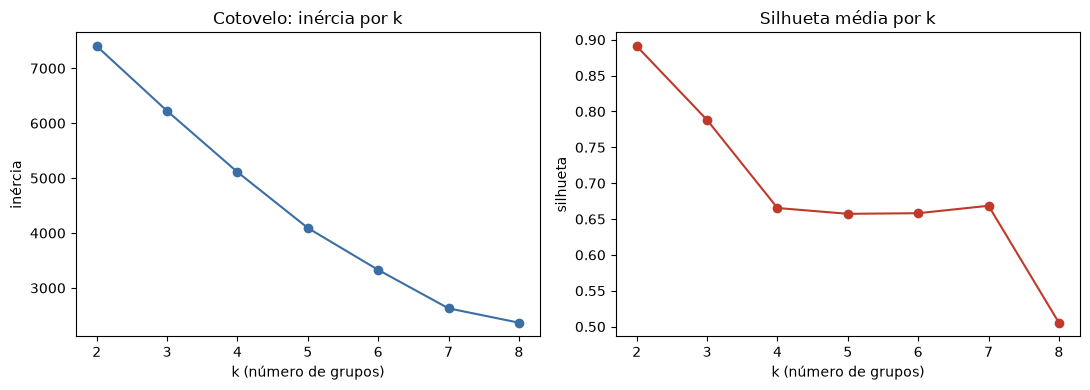

k=2: silhueta 0.891
k=3: silhueta 0.788
k=4: silhueta 0.665
k=5: silhueta 0.657
k=6: silhueta 0.658
k=7: silhueta 0.669
k=8: silhueta 0.506


In [69]:
from sklearn.metrics import silhouette_score

inercias = []
silhuetas = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_padronizado)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inercias, marker="o", color="#3b6ea5")
ax1.set_title("Cotovelo: inércia por k")
ax1.set_xlabel("k (número de grupos)"); ax1.set_ylabel("inércia")

ax2.plot(list(ks), silhuetas, marker="o", color="#c0392b")
ax2.set_title("Silhueta média por k")
ax2.set_xlabel("k (número de grupos)"); ax2.set_ylabel("silhueta")

fig.tight_layout()
plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta {s:.3f}")

In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
grupos = kmeans.fit_predict(X_padronizado)  # devolve um número de cluster (0 a 3) por cliente

exportacao["cluster"] = grupos  # guarda o cluster de cada cliente na tabela

exportacao["cluster"].value_counts().sort_index()

cluster
0    1229
1      37
2     148
3       2
Name: count, dtype: int64

In [79]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
exportacao["cluster"] = kmeans.fit_predict(X_padronizado)

# média de cada coluna, por cluster (nos valores ORIGINAIS, não nos padronizados, para ler melhor)
perfil = exportacao.groupby("cluster")[colunas_num].mean().round(1)
perfil

,likes,comments,shares,plays,author_followers,author_likes,author_videos
cluster,,,,,,,
0,60188.2,329.4,2181.6,809793.2,86531.7,17419.6,286.8
1,2114494.6,11170.1,125855.2,25040540.5,342456.8,15916.0,541.3
2,149380.3,726.8,3598.2,2308364.7,1916023.1,147138.9,1844.2
3,11300000.0,43700.0,152450.0,180850000.0,8020900.0,20017.5,395.0


0 = criadores novos ou pouco engajados, com as menores médias exceto por author_likes.

1 = criadores de médio porte, com bom engajamento e constancia consideravel.

2 = criadores fiéis na plataforma, com engajamento constante nos vídeos, apesar de postarem muito não tem tantos comentários, likes, vizualizações e engajamento.

3 = criadores grandes, com o maior engajamento, a quantidade de curtidas do criador é menor que do grupo 2 pois postam menos vídeos, mas os vídeos tem engajamento melhor.

In [80]:
# ajuste este dicionário conforme a leitura da tabela da Seção 6
nomes = {
    0: "novos / pouco engajados",
    1: "engajados de médio porte",
    2: "fiéis e constantes",
    3: "engajados de grande porte",
}
exportacao["segmento"] = exportacao["cluster"].map(nomes)

exportacao.groupby("segmento").agg(
    criadores=("id", "count"),
    comentarios=("comments", "mean"),
    compartilhamentos=("shares", "mean"),
    vizualizações=("plays", "mean"),
    porte_criador=("author_followers", "mean"),
    popularidade_criador=("author_likes", "mean"),
    presença_criador=("author_videos", "mean"),
).round(2)

,criadores,comentarios,compartilhamentos,vizualizações,porte_criador,popularidade_criador,presença_criador
segmento,,,,,,,
engajados de grande porte,2,43700.00,152450.00,1.808500e+08,8020900.00,20017.50,395.00
engajados de médio porte,37,11170.11,125855.22,2.504054e+07,342456.78,15915.97,541.32
fiéis e constantes,148,726.79,3598.18,2.308365e+06,1916023.07,147138.87,1844.18
novos / pouco engajados,1229,329.44,2181.60,8.097932e+05,86531.69,17419.62,286.83


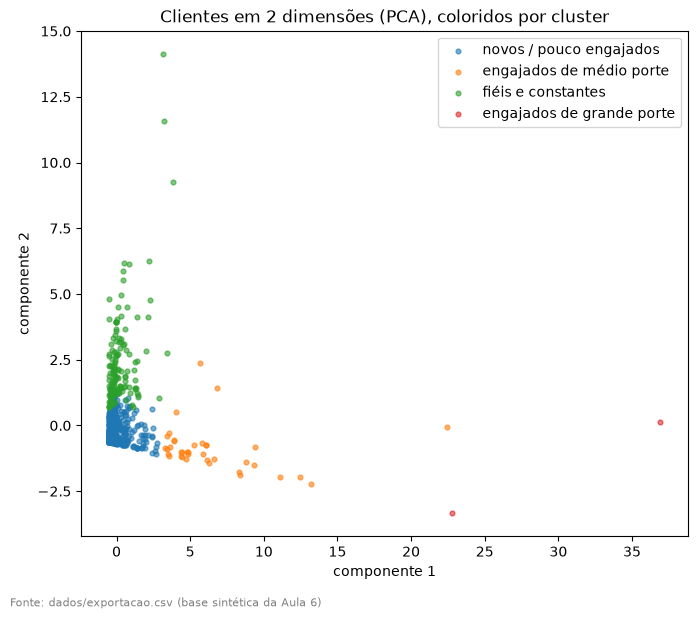

In [81]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(X_padronizado)

fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(exportacao["cluster"].unique()):
    massa = exportacao["cluster"] == c
    ax.scatter(coords[massa, 0], coords[massa, 1], s=12, alpha=0.6, label=nomes[c])
ax.set_title("Clientes em 2 dimensões (PCA), coloridos por cluster")
ax.set_xlabel("componente 1"); ax.set_ylabel("componente 2")
ax.legend()
fig.text(0.01, -0.02, "Fonte: dados/exportacao.csv (base sintética da Aula 6)", fontsize=8, color="gray")
fig.tight_layout()
plt.show()

## Parte D — README do case

Crie `README.md` dentro de `projetos/13-segmentacao-clusterizacao/` na sua pasta de entregas:

**Fonte, período e tamanho da coleta:**

> Escreva aqui.

**As duas variáveis que você criou (a contínua da Parte A e o rótulo da Parte B), com a fórmula/critério de cada uma:**

> Escreva aqui.

**As features usadas nas Partes A e B, e quais colunas você descartou por vazamento:**

> Escreva aqui.

**Parte A — resultado:** MAE e R² do modelo bobo, da linear e da árvore. O seu melhor modelo bateu o bobo?

> Escreva aqui.

**Parte B — resultado:** a matriz de confusão e uma leitura: a favor de quem o modelo erra?

> Escreva aqui.

**Parte C — resultado:** quantos segmentos, como você escolheu `k`, e a descrição de cada segmento (uma frase com número).

> Escreva aqui.

**Uma conclusão que os seus dados sustentam** (sem extrapolar para além da sua coleta):

> Escreva aqui.

**Revisão por pares:** nome do colega **da turma** que revisou, o que ele apontou, e o que você mudou (ou por que não mudou).

> Escreva aqui.

**Declaração de uso de IA:** ferramenta usada, em que trecho ou decisão, e o que você conferiu ou alterou depois (mesmo que seja "não usei IA nesta entrega"). Lembre: nesta entrega, IA não pode ser usada para gerar o código de análise.

> Escreva aqui.

## Parte E — Conferência final

- [ ] `dados/exportacao.csv` é a sua coleta, e `dados/` está no `.gitignore`.
- [ ] As duas variáveis criadas (contínua e rótulo) estão definidas e justificadas no README.
- [ ] As features das Partes A e B não incluem `likes`/`comments`/`shares`/`plays`.
- [ ] Parte A: linear, árvore e modelo bobo comparados com MAE e R².
- [ ] Parte B: matriz de confusão, precisão/recall/F1 e um threshold alternativo testado.
- [ ] Parte C: escolha de `k` justificada (cotovelo/silhueta) e um perfil por cluster com números.
- [ ] O README responde todas as perguntas da Parte D, incluindo a revisão por pares.
- [ ] Este notebook roda do início ao fim sem erro com Kernel → Restart e Run All.
- [ ] O README registra o uso de IA (ou informa que não houve). IA não gerou o código de análise.
- [ ] Notebook e README copiados em `projetos/13-segmentacao-clusterizacao/` na pasta de entregas.
- [ ] Você já fez `git add`, `git commit` e `git push`, com pelo menos um commit de progresso e um de entrega.